In [26]:
# Set some global parameters and paths
import os
import csv
import matplotlib.pyplot as plt
import numpy as np

DEBUG = False

BASE_DIR = os.path.abspath("")
ROOT_DIR = os.path.abspath(os.path.join(BASE_DIR, '../../'))
EXPERIMENTS_DIR = os.path.join(BASE_DIR, 'experiments')
RESULT_DIR = os.path.join(ROOT_DIR, 'results/lumi_mixer/cases')
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')

if DEBUG:
    print("Base Directory:", BASE_DIR)
    print("Root Directory:", ROOT_DIR)
    print("Experiments Directory:", EXPERIMENTS_DIR)
    print("Data Directory:", RESULT_DIR)
    print("Output Directory:", OUTPUT_DIR)

# Open an experiment, read the information there

Each experiment is a CSV file with headers reflecting the parameters used to
create the case files.

In [27]:
def read_experiment_file(experiment_name) -> list:
    """
    Read the experiment file and return a list of experiments with their
    parameters.

    Args:
        file_path (str): Path to the experiment CSV file.
    Returns:
        list: List of dictionaries, each representing an experiment with its
        parameters.
    """
    file_path = os.path.join(EXPERIMENTS_DIR, experiment_name)

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Experiment file not found: {file_path}")

    # Read the CSV file and parse its contents
    with open(os.path.join(file_path), 'r') as file:
        reader = csv.DictReader(file, delimiter=',', skipinitialspace=True)
        tmp = [row for row in reader]

    # Extract experiments and convert types
    experiments = []
    for row in tmp:
        experiment = {}
        for key, value in row.items():
            try:
                experiment[key] = int(value)
            except ValueError:
                try:
                    experiment[key] = float(value)
                except ValueError:
                    if value.lower() in ['true', 'false']:
                        experiment[key] = value.lower() == 'true'
                    else:
                        experiment[key] = value

        # Check if the experiment has been completed and set the status
        if os.path.exists(os.path.join(RESULT_DIR, experiment['case_name'])):
            experiment['status'] = 'done'
        else:
            experiment['status'] = 'pending'

        experiments.append(experiment)

    return experiments


In [28]:
if DEBUG:
    experiment_file = os.path.join(EXPERIMENTS_DIR, 'single_node_capacity.csv')
    experiment = read_experiment_file(experiment_file)
    print(f"Loaded {len(experiment)} experiments.")
    for exp in experiment:
        print(exp)


# Parse the log files to extract the performance metrics

In [29]:
def read_rt_stats_from_log(experiment: dict) -> list:
    """
    Read the runtime statistics from the log file.
    The runtime statistics will be stored in the experiment dictionary
    under the key 'runtimes'.

    Args:
        log_path (str): Path to the log file.
    """
    log_path = os.path.join(RESULT_DIR, experiment['case_name'],
                            experiment['case_name'] + '.log')

    if not os.path.exists(log_path):
        raise FileNotFoundError(f"Log file not found: {log_path}")

    with open(log_path, 'r') as file:
        lines = file.readlines()

    # Look for the pattern
    # `------Runtime statistics------` followed by an empty line
    # Then read the following table until an empty line is found

    start_index = None
    for i, line in enumerate(lines):
        if '------Runtime statistics------' in line:
            start_index = i + 2  # Skip the next empty line
            break
    if start_index is None:
        raise ValueError("Runtime statistics section not found in log file.")

    end_index = start_index
    while end_index < len(lines) and lines[end_index].strip():
        end_index += 1

    # Extract the relevant lines
    stats_lines = lines[start_index:end_index]

    # Parse the statistics lines into a structured format
    header = ["Region name", "Total time", "Avg time", "Range +/-"]

    data = {}
    for line in stats_lines[2:]:
        parts = line.strip().split()
        if len(parts) >= 4:
            region_name = " ".join(parts[:-3])
            total_time = float(parts[-3])
            avg_time = float(parts[-2])
            range_plus_minus = float(parts[-1])

            data[region_name] = {
                header[1]: total_time,
                header[2]: avg_time,
                header[3]: range_plus_minus
            }
    experiment['runtimes'] = data


In [30]:
# Parse the log files to extract the performance metrics
if DEBUG:
    read_rt_stats_from_log(experiment[1])
    print("Parsed Statistics Data:")
    for region, times in experiment[1]['runtimes'].items():
        print(f"Region: '{region}'")
        for key, value in times.items():
            print(f"   '{key}': {value}")


In [31]:
def extract_times(experiment: list,
                  region: str,
                  measure: str = 'Avg time') -> np.ndarray:
    """
    Extract specific timing data from the experiment's runtimes.

    Args:
        experiment (list): The experiment dictionary containing runtimes.
        region (str): The region name to extract.
        measure (str): The measure to extract (default is 'Avg Time').
                       Possible values:  'Total time' 'Avg. time' 'Range +/-'

    Returns:
        np.ndarray: Array of extracted times.
    """

    result = np.array([])
    for exp in experiment:
        if exp['status'] != 'done':
            continue

        if 'runtimes' not in exp:
            read_rt_stats_from_log(exp)

        if 'runtimes' in exp and region in exp['runtimes']:
            result = np.append(result, exp['runtimes'][region][measure])

    return result

# Single node capacity analysis

Here we have investigated the effect of adding more elements onto a single node
of LUMi. This will help us choose the right mesh size for a given problem.

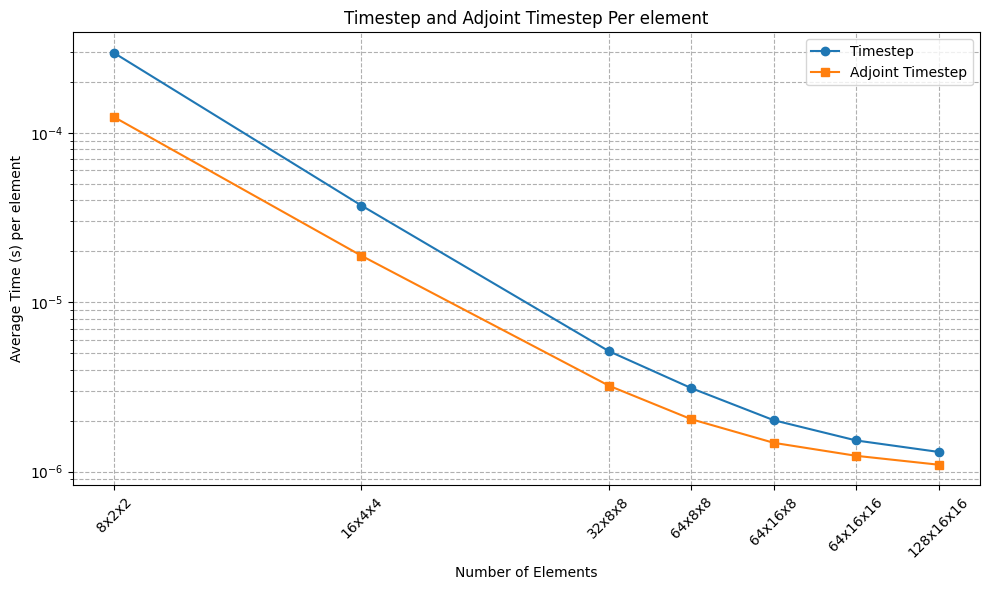

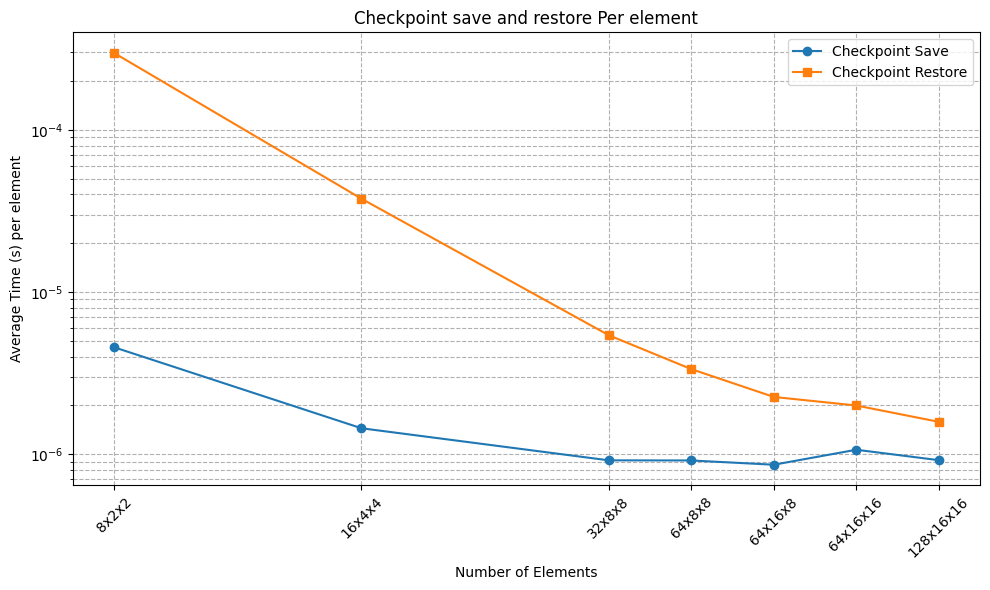

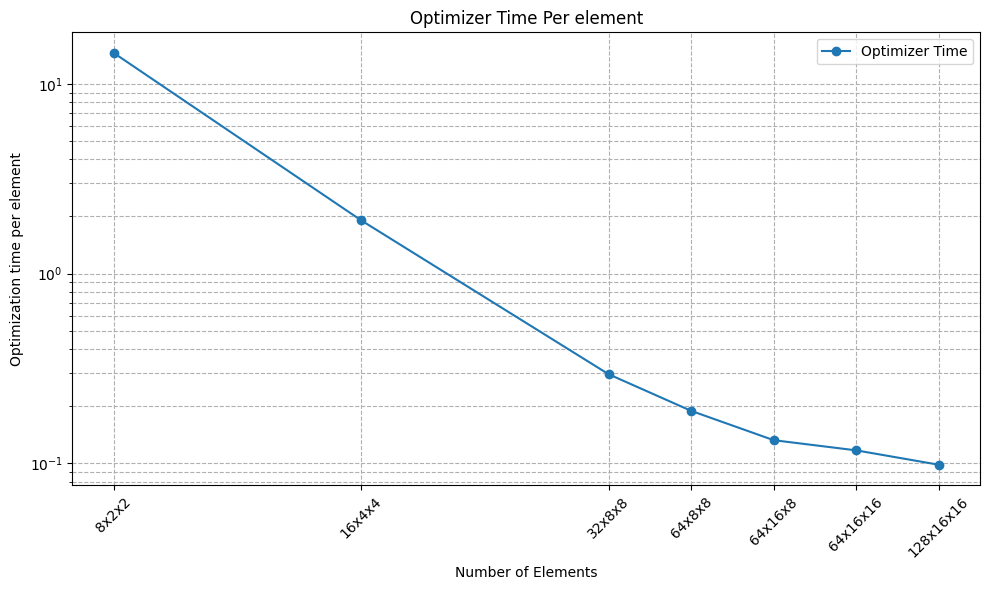

In [32]:
# Plot the timestep and adjoint timestep as a function of the number of elements

experiment = read_experiment_file('single_node_capacity.csv')

num_elements = np.array([])
timestep = np.array([])
adjoint_timestep = np.array([])
checkpoint_save = np.array([])
checkpoint_restore = np.array([])
optimizer_time = np.array([])

num_elements = np.array([
    exp['Nx'] * exp['Ny'] * exp['Nz'] for exp in experiment
    if exp['status'] == 'done'
])
mesh_labels = np.array([
    f"{exp['Nx']}x{exp['Ny']}x{exp['Nz']}" for exp in experiment
    if exp['status'] == 'done'
])

timestep = extract_times(experiment, 'Time-Step')
adjoint_timestep = extract_times(experiment, 'Time-Step Adjoint')
checkpoint_save = extract_times(experiment, 'Checkpoint save')
checkpoint_restore = extract_times(experiment, 'Checkpoint restore')
optimizer_time = extract_times(experiment, 'Optimizer iteration 0', 'Total time') + \
                 extract_times(experiment, 'Optimizer iteration', 'Total time')

plt.figure(figsize=(10, 6))
plt.plot(num_elements, timestep / num_elements, marker='o', label='Timestep')
plt.plot(num_elements,
         adjoint_timestep / num_elements,
         marker='s',
         label='Adjoint Timestep')

#  Set xscale to be log2 and yscale to be log10
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xlabel('Number of Elements')
plt.ylabel('Average Time (s) per element')
plt.xticks(num_elements, mesh_labels, rotation=45)
plt.title('Timestep and Adjoint Timestep Per element')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()

plt.figure(figsize=(10, 6))
plt.plot(num_elements,
         checkpoint_save / num_elements,
         marker='o',
         label='Checkpoint Save')
plt.plot(num_elements,
         checkpoint_restore / num_elements,
         marker='s',
         label='Checkpoint Restore')

#  Set xscale to be log2 and yscale to be log10
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xlabel('Number of Elements')
plt.ylabel('Average Time (s) per element')
plt.xticks(num_elements, mesh_labels, rotation=45)
plt.title('Checkpoint save and restore Per element')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()

plt.figure(figsize=(10, 6))
plt.plot(num_elements,
         optimizer_time / num_elements,
         marker='o',
         label='Optimizer Time')

#  Set xscale to be log2 and yscale to be log10
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xlabel('Number of Elements')
plt.ylabel('Optimization time per element')
plt.xticks(num_elements, mesh_labels, rotation=45)
plt.title('Optimizer Time Per element')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()